In [1]:
# conda activate chronocell

import os
import sys
import time
import pickle
import pandas as pd

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint/code")

import Chronocell
from reconstruct_RNA_history import *

from threadpoolctl import threadpool_limits
threadpool_limits(10)

In [2]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [3]:
# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [4]:
Y = traj.X
Q = traj.Q[:, 0, :] 
tau = traj.tau # State transition times (global)
t = traj.t
theta = traj.theta
topo = traj.topo
state_grid = np.searchsorted(tau, t, side="left") - 1
state_grid[0] = 0 

# Do this below with subset of genes

# theta_ = theta.copy()
# a0 = theta_[:, 0] # Starting RNA abundance 
# a = theta_[:, 1:len(topo.flatten())] 
# beta = theta_[:, -2] # Splicing rate
# alpha = a * beta[:, None] # These values are divided by splicing rate; removing this factor now
# gamma = theta_[:, -1] # Degradation rate

## Subset to genes with protein measurements

In [ ]:
genes = pd.read_csv(f"data/{prefix}.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist() # Genes to focus on

### What is the max # of counts for these genes?

In [6]:
mapped_mean_expr_U = Y[:, gene_idx, 0].max(axis=0)
mapped_mean_expr_S = Y[:, gene_idx, 1].max(axis=0)

In [7]:
np.sort(mapped_mean_expr_U)

array([  1.,   1.,   2.,   3.,   3.,   3.,   3.,   3.,   3.,   3.,   3.,
         4.,   4.,   4.,   6.,   6.,   6.,   6.,   6.,   7.,   7.,   8.,
         9.,  10.,  11.,  11.,  12.,  14.,  14.,  16.,  16.,  16.,  19.,
        19.,  22.,  22.,  24.,  25.,  27.,  27.,  38.,  42.,  46.,  54.,
        56.,  60., 115.])

In [8]:
np.sort(mapped_mean_expr_S)

array([  4.,   4.,   5.,   5.,   5.,   5.,   6.,   7.,   7.,   7.,   7.,
         7.,   7.,   8.,   8.,   8.,   8.,   8.,   8.,   9.,  10.,  10.,
        10.,  11.,  11.,  11.,  12.,  12.,  13.,  13.,  14.,  16.,  16.,
        16.,  18.,  20.,  21.,  25.,  27.,  27.,  28.,  35.,  35.,  43.,
        54.,  99., 105.])

In [9]:
Y = Y[:, gene_idx, :]
theta = theta[gene_idx, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [8]:
# Gene names

gene_df = genes['Gene_symbol'][gene_idx]

In [11]:
gene_df

3        Cxcr4
9         Icos
12        Cd48
15       Sbno2
18       Cd24a
22        Cd63
25        Cd68
28        Ccr7
33      Havcr2
48        Ighm
59        Irf4
63        Cd83
70      Lgals3
73        Il7r
82        Ly6e
88        Cd86
90       Cd200
93        Cd80
94        Btla
107      Ms4a1
109      Cd274
110        Fas
116       Dpp4
126      Itga4
128      Procr
134      Cd1d1
137      Vcam1
148    Tnfrsf4
149       Cd36
154      Sbno1
155       Flt3
156       Cd38
157        Kit
164        Cd9
167      Klrk1
171       Cd8a
173    Clec12a
174     Clec9a
176       Pirb
179      Il4ra
180      Itgal
181      Itgax
183       Bst2
187      Lamp1
191      Itgb1
197       Xcr1
199      Icam1
Name: Gene_symbol, dtype: object

In [12]:
outdir = "data/RNA_history_per_gene"

## Reconstruct RNA

In [14]:
from threadpoolctl import threadpool_info
threadpool_info()

[{'user_api': 'blas',
  'internal_api': 'openblas',
  'num_threads': 10,
  'prefix': 'libopenblas',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libopenblasp-r0.3.29.so',
  'version': '0.3.29',
  'threading_layer': 'pthreads',
  'architecture': 'SkylakeX'},
 {'user_api': 'openmp',
  'internal_api': 'openmp',
  'num_threads': 10,
  'prefix': 'libgomp',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libgomp.so.1.0.0',
  'version': None}]

In [20]:
sparse_cutoff = 50

In [21]:
X_fwd_per_gene = []
states_per_gene = []

n_genes = Y.shape[1]

for gene_idx in range(0, n_genes):
    # Set max # of RNAs based on observed values
    U_max, S_max = max_RNAs(Y, gene_idx)

    print("==================================")
    print(f"Starting gene {gene_idx + 1} out of {n_genes}")
    print("U_max, S_max:", U_max, S_max)
    
    gene_name = gene_df.iloc[gene_idx]
     
    states, index_for = enumerate_states(U_max, S_max)

    beta_j = beta[gene_idx]
    gamma_j = gamma[gene_idx] 
    alpha_j = alpha[gene_idx, :]
    Y_j = Y[:, gene_idx, :]

    # Make generator matrix (per transcription rate)
    A = []
    for i in range(0, alpha.shape[1]):
        rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
        if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
            A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
        else:
            A1 = create_transition_matrix(rxns, states, index_for, U_max, S_max)
        A.append(A1)
    
    # Calculate forward probability distributions (needed for reverse generator)
    alpha0 = a0[gene_idx] * beta_j
    pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
    start = time.perf_counter() 
    X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
    end = time.perf_counter()
    print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")
    
    # Calculate backward probability distributions
    
    start = time.perf_counter()
    if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
        X_bw = backward_distribution_sparse_to_dense(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution_sparse_to_dense(): {end - start:.6f} seconds")
    else:
        X_bw = backward_distribution(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution(): {end - start:.6f} seconds")

    # Save highest probability state
    start = time.perf_counter()
    U_per_cell, S_per_cell = highest_prob_state_in_X_bw(X_bw, Q, states) 
    end = time.perf_counter()
    print(f"Elapsed time for highest_prob_state_in_X_bw(): {end - start:.6f} seconds")
         
    with open(f"{outdir}/{prefix}_{gene_name}_U_RNA_history.pkl", "wb") as f:
        pickle.dump(U_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    with open(f"{outdir}/{prefix}_{gene_name}_S_RNA_history.pkl", "wb") as f:
        pickle.dump(S_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    X_fwd_per_gene.append(X_fwd)
    states_per_gene.append(states)
    
    get_expm.cache_clear()
    get_A_rev.cache_clear()
    get_expm_rev.cache_clear()
    get_A_rev_sparse_to_dense.cache_clear()
    get_expm_rev_sparse_to_dense.cache_clear()

Starting gene 1 out of 47
U_max, S_max: 5 14
Elapsed time for forward_distribution_blocked(): 0.236552 seconds
Elapsed time for backward_distribution(): 1.415594 seconds
Elapsed time for highest_prob_state_in_X_bw(): 1.086960 seconds
Starting gene 2 out of 47
U_max, S_max: 16 9
Elapsed time for forward_distribution_blocked(): 0.267203 seconds
Elapsed time for backward_distribution(): 2.651691 seconds
Elapsed time for highest_prob_state_in_X_bw(): 2.726858 seconds
Starting gene 3 out of 47
U_max, S_max: 4 8
Elapsed time for forward_distribution_blocked(): 0.115653 seconds
Elapsed time for backward_distribution(): 0.566918 seconds
Elapsed time for highest_prob_state_in_X_bw(): 0.441388 seconds
Starting gene 4 out of 47
U_max, S_max: 7 6
Elapsed time for forward_distribution_blocked(): 0.063414 seconds
Elapsed time for backward_distribution(): 0.571152 seconds
Elapsed time for highest_prob_state_in_X_bw(): 0.544817 seconds
Starting gene 5 out of 47
U_max, S_max: 4 18
Elapsed time for forw

In [22]:
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "wb") as f:
    pickle.dump(X_fwd_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
with open(f"data/{prefix}_states_per_gene.pkl", "wb") as f:
    pickle.dump(states_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)

## Compare reconstructed vs. forward trajectories

In [23]:
import glob
import matplotlib.pyplot as plt

In [25]:
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)
    
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)

In [26]:
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")
from protein_from_RNA import *

n = 1000
random_seed = 666

Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

In [27]:
gene_idx = 20

In [28]:
# Get forward states
states = states_per_gene[gene_idx]
X_fwd = X_fwd_per_gene[gene_idx]
U_fwd, S_fwd = highest_prob_state_in_X_fwd(X_fwd, states)

In [29]:
# Load backward states
gene_str = gene_df.iloc[gene_idx]
pattern = os.path.join(outdir, f"*_{gene_str}_S*")
file = glob.glob(pattern)[0]

with open(file, "rb") as f:
    X_bw_S = pickle.load(f)

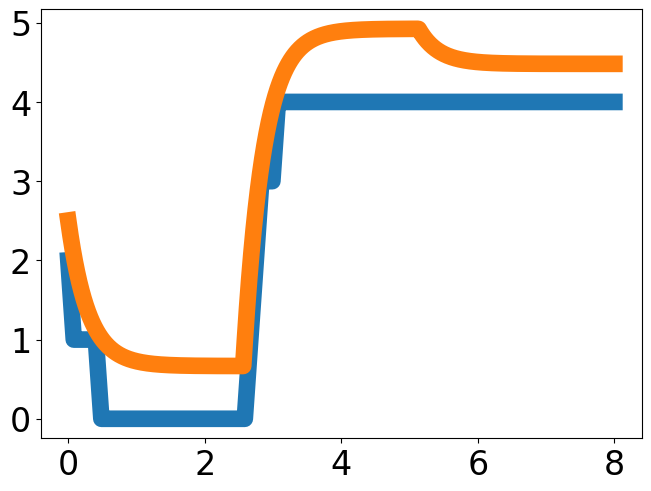

In [30]:
plt.plot(t, U_fwd)
plt.plot(true_t, Y[:, gene_idx, 0])

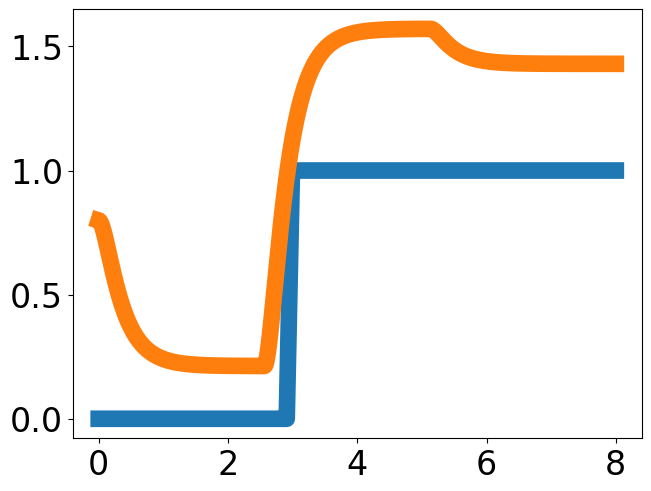

In [33]:
plt.plot(t, S_fwd)
plt.plot(true_t, Y[:, gene_idx, 1])

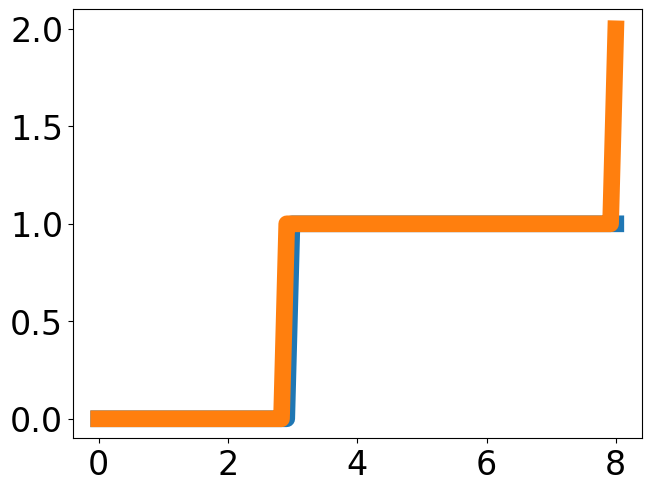

In [34]:
# Pick cell at the end of trajectory:

t_obs = np.argmax(Q, axis=1)
end_cells = np.where(t_obs == 99)[0]
X_bw_S_mean = X_bw_S[end_cells, :].mean(axis=1)

plt.plot(t, S_fwd)
plt.plot(t, X_bw_S[end_cells[19], :])

In [ ]:
# Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta[0, :][None, :], n=20000, random_seed=666)